In [2]:
import rasterio
import numpy as np
import glob
import os
import rasterio
from rasterio.merge import merge
import glob
import os

# Merge Raster Images

In [3]:
Base = '/Users/wenlanzhang/Downloads/PhD_UCL/Data/RS/Maxar/'

pre = '20231130/'
post = '20240511/'

In [3]:
# Correct: Merge all RS files and remove big black boundary

# Define input & output file paths
image_folder = Base + post +  "Visual/" 
output_cropped = Base + post + "Visual_merged.tif"

# Get list of all raster images (.tif)
raster_files = glob.glob(os.path.join(image_folder, "*.tif"))

# Open all raster files
src_files = [rasterio.open(file) for file in raster_files]

# Merge rasters while preserving black pixels (do not set nodata=0)
merged_raster, transform = merge(src_files, method="first")

# Convert to NumPy array (multi-band)
merged_data = merged_raster  # Shape: (bands, height, width)

# Identify fully black rows/columns across ALL bands
mask = np.any(merged_data != 0, axis=0)  # True if any band has a non-zero value

# Get the first and last non-black rows/columns
non_black_rows = np.where(mask.max(axis=1) > 0)[0]
non_black_cols = np.where(mask.max(axis=0) > 0)[0]

# Crop boundaries
if non_black_rows.size > 0 and non_black_cols.size > 0:
    row_min, row_max = non_black_rows[0], non_black_rows[-1] + 1
    col_min, col_max = non_black_cols[0], non_black_cols[-1] + 1
    cropped_data = merged_data[:, row_min:row_max, col_min:col_max]  # Keep all bands
    
    # Update transform to match new cropped dimensions
    new_transform = transform * rasterio.Affine.translation(col_min, row_min)

    # Get metadata from the first image
    out_meta = src_files[0].meta.copy()
    
    # Update metadata for cropped raster
    out_meta.update({
        "driver": "GTiff",
        "height": cropped_data.shape[1],  # Height (rows)
        "width": cropped_data.shape[2],   # Width (cols)
        "transform": new_transform
    })

    # Save cropped raster
    with rasterio.open(output_cropped, "w", **out_meta) as dest:
        dest.write(cropped_data)  # Write all bands

    print(f"Cropped raster saved as {output_cropped} (black borders removed)")

# Close all raster files
for src in src_files:
    src.close()

Cropped raster saved as /Users/wenlanzhang/Downloads/PhD_UCL/Data/RS/Maxar/20240511/Visual_merged.tif (black borders removed)


In [4]:
# 20240511/Visual/ 应该不会死kernel，试试

import rasterio
from rasterio.merge import merge
import numpy as np
import os
import glob

# Define input & output file paths
image_folder = os.path.join(Base, "20240511/Visual/")
output_cropped = os.path.join(Base, "20240511/Visual_merged.tif")

# Get list of all raster images (.tif)
raster_files = glob.glob(os.path.join(image_folder, "*.tif"))

# Open rasters one by one (do NOT load all into memory)
src_files = [rasterio.open(file) for file in raster_files]

# MERGE RASTERS EFFICIENTLY (Disk-Based Processing)
merged_raster, transform = merge(src_files, method="first")  

# Avoid memory issues by processing in smaller chunks
with rasterio.MemoryFile() as memfile:
    with memfile.open(
        driver="GTiff",
        height=merged_raster.shape[1],  # Merged height
        width=merged_raster.shape[2],   # Merged width
        count=merged_raster.shape[0],   # Number of bands
        dtype=merged_raster.dtype,
        crs=src_files[0].crs,
        transform=transform,
    ) as merged_ds:
        merged_ds.write(merged_raster)

        # READ AS BLOCKS TO FIND BLACK BORDERS (No Full Memory Load)
        mask = np.any(merged_raster != 0, axis=0)  # Keep areas where ANY band has nonzero data
        non_black_rows = np.where(mask.max(axis=1) > 0)[0]
        non_black_cols = np.where(mask.max(axis=0) > 0)[0]

        if non_black_rows.size > 0 and non_black_cols.size > 0:
            row_min, row_max = non_black_rows[0], non_black_rows[-1] + 1
            col_min, col_max = non_black_cols[0], non_black_cols[-1] + 1

            # CROP USING A WINDOW INSTEAD OF LOADING EVERYTHING
            window = rasterio.windows.Window(col_min, row_min, col_max - col_min, row_max - row_min)
            cropped_data = merged_ds.read(window=window)

            # Adjust transform for cropped data
            new_transform = transform * rasterio.Affine.translation(col_min, row_min)

            # Update metadata for cropped raster
            out_meta = merged_ds.meta.copy()
            out_meta.update({
                "height": cropped_data.shape[1],
                "width": cropped_data.shape[2],
                "transform": new_transform
            })

            # WRITE TO DISK WITHOUT OVERLOADING RAM
            with rasterio.open(output_cropped, "w", **out_meta) as dest:
                dest.write(cropped_data)  # Save all bands

            print(f"Cropped raster saved as {output_cropped} (black borders removed)")

# Close all raster files
for src in src_files:
    src.close()


KeyboardInterrupt: 

In [14]:
# # 有黑边

# # Define the directory containing the images
# image_folder = Base + "20231130/Visual/"  # Change this to your actual folder
# output_file = Base + "20231130/Visual_merged2.tif"  # Output filename

# # Get list of all raster images (.tif)
# raster_files = glob.glob(os.path.join(image_folder, "*.tif"))

# # Open all raster files (DO NOT SET nodata=0, to preserve real 0-values)
# src_files = [rasterio.open(file) for file in raster_files]

# # Merge rasters WITHOUT setting nodata=0 (preserving actual 0-values)
# merged_raster, transform = merge(src_files, method="first")  

# # Get metadata from the first image
# out_meta = src_files[0].meta.copy()

# # Update metadata for merged raster
# out_meta.update({
#     "driver": "GTiff",
#     "height": merged_raster.shape[1],
#     "width": merged_raster.shape[2],
#     "transform": transform
#     # DO NOT set nodata=0, to keep real black pixels
# })

# # Save merged raster (preserving all 0-values)
# with rasterio.open(output_file, "w", **out_meta) as dest:
#     dest.write(merged_raster)

# # Close all raster files
# for src in src_files:
#     src.close()

# print(f"Merged raster saved as {output_file} (black pixels preserved)")


Merged raster saved as /Users/wenlanzhang/Downloads/PhD_UCL/Data/RS/Maxar/20231130/Visual_merged2.tif (black pixels preserved)


# Clip to overlap

In [12]:
import rasterio
from rasterio.mask import mask
import numpy as np
from shapely.geometry import box
import geopandas as gpd

# Define file paths
pre_flood_path = Base + "20231130/MS_croped.tif"
post_flood_path = Base + "20240511/MS_croped.tif"
clipped_pre_flood_path = Base + "20231130/MS2_cliped.tif"
clipped_post_flood_path = Base + "20240511/MS2_cliped.tif"

# Open both images to get their bounds
with rasterio.open(pre_flood_path) as src_pre, rasterio.open(post_flood_path) as src_post:
    bounds_pre = box(*src_pre.bounds)  # Convert bounds to Shapely box
    bounds_post = box(*src_post.bounds)  # Convert bounds to Shapely box

    # Find the intersection (common area)
    common_bounds = bounds_pre.intersection(bounds_post)
    
    # Convert to GeoJSON format
    common_geom = gpd.GeoSeries(common_bounds).__geo_interface__["features"][0]["geometry"]

    # Clip pre-flood image
    pre_clipped, pre_transform = mask(src_pre, [common_geom], crop=True)
    pre_meta = src_pre.meta.copy()
    pre_meta.update({"height": pre_clipped.shape[1], "width": pre_clipped.shape[2], "transform": pre_transform})

    # Clip post-flood image
    post_clipped, post_transform = mask(src_post, [common_geom], crop=True)
    post_meta = src_post.meta.copy()
    post_meta.update({"height": post_clipped.shape[1], "width": post_clipped.shape[2], "transform": post_transform})

# Save clipped pre-flood image
with rasterio.open(clipped_pre_flood_path, "w", **pre_meta) as dst:
    dst.write(pre_clipped)

# Save clipped post-flood image
with rasterio.open(clipped_post_flood_path, "w", **post_meta) as dst:
    dst.write(post_clipped)

print(f"Clipped images saved as {clipped_pre_flood_path} and {clipped_post_flood_path}")


Clipped images saved as /Users/wenlanzhang/Downloads/PhD_UCL/Data/RS/Maxar/20231130/MS2_cliped.tif and /Users/wenlanzhang/Downloads/PhD_UCL/Data/RS/Maxar/20240511/MS2_cliped.tif


# Processing (MS)

In [11]:
# TOA Reflectance Calculation

import numpy as np
import rasterio

# Constants (Example for WorldView-3)
ESUN = { "Blue": 1884, "Green": 1665, "Red": 1551, "NIR": 1150 }  # Solar irradiance values (W/m^2/μm)
d = 1.0  # Earth-Sun distance in AU (depends on date)
theta_s = np.deg2rad(45)  # Example sun elevation (change based on metadata)

def dn_to_toa(dn_array, gain, offset, esun, d, theta_s):
    """Convert DN to TOA Reflectance."""
    radiance = (dn_array * gain) + offset  # Convert DN to radiance
    toa_reflectance = (np.pi * radiance * d**2) / (esun * np.cos(theta_s))
    return np.clip(toa_reflectance, 0, 1)  # Normalize reflectance values

# Read multispectral image
with rasterio.open("/Users/wenlanzhang/Downloads/PhD_UCL/Data/RS/Maxar/20240511/MS_croped.tif") as src:
    metadata = src.meta
    dn_data = src.read()

# Apply TOA conversion for each band
toa_blue = dn_to_toa(dn_data[0], gain=0.02, offset=0, esun=ESUN["Blue"], d=d, theta_s=theta_s)
toa_green = dn_to_toa(dn_data[1], gain=0.02, offset=0, esun=ESUN["Green"], d=d, theta_s=theta_s)
toa_red = dn_to_toa(dn_data[2], gain=0.02, offset=0, esun=ESUN["Red"], d=d, theta_s=theta_s)

# Save TOA reflectance image
metadata.update(dtype='float32')
with rasterio.open("/Users/wenlanzhang/Downloads/PhD_UCL/Data/RS/Maxar/20240511/MS_toa_reflectance.tif", "w", **metadata) as dst:
    dst.write(toa_blue, 1)
    dst.write(toa_green, 2)
    dst.write(toa_red, 3)


In [12]:
# Atmospheric Correction: Dark Object Subtraction

def dark_object_subtraction(band):
    """Perform Dark Object Subtraction (DOS) to remove haze."""
    min_pixel_value = np.percentile(band, 1)  # Get 1st percentile as haze estimate
    return np.clip(band - min_pixel_value, 0, 1)  # Ensure no negative values

# Apply DOS to each band
dos_blue = dark_object_subtraction(toa_blue)
dos_green = dark_object_subtraction(toa_green)
dos_red = dark_object_subtraction(toa_red)

# Save DOS-corrected image
with rasterio.open("/Users/wenlanzhang/Downloads/PhD_UCL/Data/RS/Maxar/20240511/MS_dos_corrected.tif", "w", **metadata) as dst:
    dst.write(dos_blue, 1)
    dst.write(dos_green, 2)
    dst.write(dos_red, 3)


2.2. Advanced Atmospheric Correction (FLAASH / QUAC in ENVI)
For highly atmospheric-distorted images, use FLAASH or QUAC in ENVI software.  

Using FLAASH in ENVI  
Open ENVI → Toolbox → Radiometric Correction → FLAASH Atmospheric Correction.  
Select input TOA reflectance image.  
Set:  
Sensor type (e.g., WorldView-3).  
Water vapor amount (from metadata).  
Aerosol model (rural, urban, maritime, etc.).  
Run the correction.  
Save the output.  
Using QUAC in ENVI  
Open ENVI → Toolbox → Radiometric Correction → Quick Atmospheric Correction (QUAC).  
Select the TOA reflectance image.  
Run automatic atmospheric correction (QUAC does not require detailed parameters).  
Save the corrected image.    
✅ FLAASH is physics-based and more accurate than DOS or QUAC, but it requires more input data.  

# normalize the post-flood image to match the pre-flood image 
using histogram matching with skimage.exposure.match_histograms

1. Resample Post-Flood Image to Match Pre-Flood Image
We will resample the post-flood image using rasterio.warp.reproject to align it with the pre-flood image.

2. Apply Histogram Matching After Resampling
Once the dimensions match, we can safely apply histogram matching.


In [3]:
import rasterio
import numpy as np
from rasterio.enums import Resampling
from rasterio.warp import reproject, calculate_default_transform
from skimage.exposure import match_histograms

# Define input file paths
pre_flood_path = Base + "20231130/MS_cliped.tif"
post_flood_path = Base + "20240511/MS_cliped.tif"
output_path = Base + "normalized_post_flood.tif"

# Open the pre-flood multispectral image
with rasterio.open(pre_flood_path) as src_pre:
    pre_flood = src_pre.read()  # Read all bands
    metadata = src_pre.meta  # Store metadata
    pre_transform = src_pre.transform
    pre_crs = src_pre.crs

# Open the post-flood multispectral image
with rasterio.open(post_flood_path) as src_post:
    post_flood = src_post.read()  # Read all bands
    post_transform = src_post.transform
    post_crs = src_post.crs

    # If the spatial resolution or dimensions don't match, resample the post-flood image
    if (src_post.width != src_pre.width) or (src_post.height != src_pre.height) or (src_post.crs != src_pre.crs):
        print("Resampling post-flood image to match pre-flood dimensions...")

        # Calculate new transform and dimensions
        transform, width, height = calculate_default_transform(
            src_post.crs, src_pre.crs, src_pre.width, src_pre.height, *src_pre.bounds
        )

        # Update metadata
        new_metadata = src_post.meta.copy()
        new_metadata.update({"crs": src_pre.crs, "transform": transform, "width": width, "height": height})

        # Create an empty array for resampled data
        resampled_post_flood = np.zeros((src_pre.count, height, width), dtype=src_post.dtypes[0])

        # Reproject each band to match the pre-flood image
        for i in range(src_post.count):
            reproject(
                source=post_flood[i],
                destination=resampled_post_flood[i],
                src_transform=post_transform,
                src_crs=post_crs,
                dst_transform=transform,
                dst_crs=pre_crs,
                resampling=Resampling.bilinear
            )
    else:
        resampled_post_flood = post_flood  # No resampling needed

# Apply histogram matching for each spectral band
normalized_post_flood = np.zeros_like(pre_flood, dtype=np.float32)

for band in range(pre_flood.shape[0]):  # Loop through each band
    normalized_post_flood[band] = match_histograms(resampled_post_flood[band], pre_flood[band])

# Save the normalized post-flood image
metadata.update(dtype='float32')

with rasterio.open(output_path, "w", **metadata) as dst:
    dst.write(normalized_post_flood)

print(f"Normalized post-flood image saved as {output_path}")


Resampling post-flood image to match pre-flood dimensions...
Normalized post-flood image saved as /Users/wenlanzhang/Downloads/PhD_UCL/Data/RS/Maxar/normalized_post_flood.tif


#  Retry

In [4]:
import rasterio
import numpy as np
import matplotlib.pyplot as plt
import cv2
from rasterio.plot import show
from skimage.filters import threshold_otsu
from skimage.morphology import remove_small_objects

Pre event data: WorldView-3, 0.32m  
Post event data: GeoEye-1, 0.69m     

plan:  
1. Data Preparation
Before performing flood detection, ensure the datasets are comparable:

Resample Post-Event Data: WorldView-3 has a higher resolution (0.32m) than GeoEye-1 (0.69m). Use bilinear or cubic resampling to match resolutions.
Co-register Images: Align images spatially to correct for geometric distortions.
Atmospheric Correction: Normalize spectral differences caused by different sun angles and atmospheric conditions.  

2. Water Body Extraction (Pre-Event)
Extract pre-existing water bodies to differentiate them from floodwaters.
- Use NDWI (Normalized Difference Water Index):

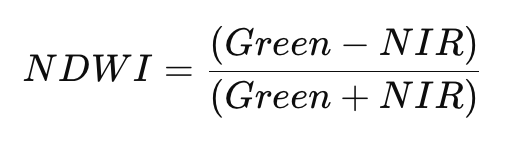

    Green: WorldView-3 Band 3 (510–580 nm)
    NIR: WorldView-3 Band 8 (770–895 nm)
    Threshold: NDWI > 0.2 usually represents water.
- Create a Water Mask: Convert NDWI results into a binary water mask for the pre-event image.

3. Change Detection (Pre vs. Post Event)
Detect changes that indicate new water accumulation (flooded areas).

a. NDWI Difference
- Compute NDWI for both pre- and post-event images.
- Generate a difference map:
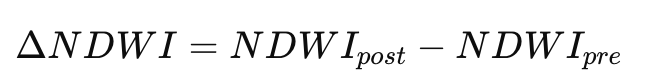 
- Set a threshold (e.g., ΔNDWI > 0.2) to classify new water.

b. SAR-like Water Mapping (if using only RGB)  
Since GeoEye-1 does not have NIR, you can use:  
- HSV Transformation: Convert RGB to HSV and detect regions with high blue reflectance.
- K-Means Clustering: Group pixels into "water" vs. "non-water" based on brightness.
c. Texture-Based Flood Detection
If floodwaters have muddy sediment, use:

- Gabor Filters: Identify texture changes.
- Edge Detection (Sobel/Canny): Detect water extent changes.

4. Validation & Refinement
Compare with DEM (Digital Elevation Model): Remove water misclassified on high terrain.
Use Historical Water Masks (JRC Global Surface Water, Sentinel-2, or OpenStreetMap Water Bodies).
Manual Validation: Compare high-confidence flood areas with external flood reports.

5. Output Generation
Flood Mask: Binary raster highlighting newly inundated areas.
Flood Extent Map: Overlay the flood mask onto pre-event imagery for visualization.
Statistics: Compute total flooded area and percentage increase in water coverage.


In [ ]:
# import rasterio
# import numpy as np

# # Set No data value: Change black to transparent 

# # Open the raster file
# with rasterio.open(Base + "20240511/MS_croped.tif") as src:
#     image = src.read()
#     meta = src.meta

#     # Find areas where all bands are zero
#     mask_array = np.all(image == 0, axis=0)  # True where all bands are 0

#     # Assign NoData value instead of NaN
#     nodata_value = 65535 # Choose an appropriate NoData value (-9999?)
#     image[:, mask_array] = nodata_value

#     # Update metadata with NoData value
#     meta.update(nodata=nodata_value, dtype='int32')  # Ensure correct dtype

#     # Save the modified image
#     with rasterio.open("/Users/wenlanzhang/Downloads/PhD_UCL/Data/RS/Maxar/20240511/MS2_cleaned.tif", "w", **meta) as dst:
#         dst.write(image)


In [30]:
# import rasterio
# import numpy as np

# # Mask file: Change black to transparent 

# # Open the raster file
# with rasterio.open(Base + "20240511/MS_croped.tif") as src:
#     # Read the raster image as an array (bands, height, width)
#     image = src.read()
    
#     # Copy metadata
#     meta = src.meta.copy()
    
#     # Find areas where all bands are zero
#     mask_array = np.all(image == 0, axis=0)  # True where all bands are 0
    
#     # Expand dimensions of the mask to match the image shape (bands, height, width)
#     mask_array_expanded = np.expand_dims(mask_array, axis=0)  # (1, height, width)
#     mask_array_expanded = np.repeat(mask_array_expanded, image.shape[0], axis=0)  # Repeat for each band
    
#     # Create a masked array
#     masked_image = np.ma.masked_array(image, mask=mask_array_expanded)
    
#     # Define a NoData value (choose based on dtype)
#     if meta['dtype'] == 'uint16':
#         nodata_value = 65535  # Max value for uint16
#     elif meta['dtype'].startswith('int'):
#         nodata_value = -9999  # Suitable for int types
#     else:
#         nodata_value = np.nan  # Use NaN for float types

#     # Update metadata with NoData value
#     meta.update(nodata=nodata_value, dtype='float32' if np.isnan(nodata_value) else meta['dtype'])

#     # Save the masked image (replace masked values with NoData value)
#     with rasterio.open(Base + "20240511/masked_image.tif", "w", **meta) as dst:
#         dst.write(masked_image.filled(nodata_value).astype(meta['dtype']))


这里在QGIS里面画了个shp文件, 用RS的CRS然后裁剪了两个图

In [26]:
import rasterio
from rasterio.mask import mask
import numpy as np
from shapely.geometry import box
import geopandas as gpd

# Get common area (No data still exist)

# Define file paths
pre_flood_path = Base + "20231130/MS2_cleaned.tif"
post_flood_path = Base + "20240511/MS2_cleaned.tif"
clipped_pre_flood_path = Base + "20231130/MS2_cliped.tif"
clipped_post_flood_path = Base + "20240511/MS2_cliped.tif"

# Open both images to get their bounds
with rasterio.open(pre_flood_path) as src_pre, rasterio.open(post_flood_path) as src_post:
    bounds_pre = box(*src_pre.bounds)  # Convert bounds to Shapely box
    bounds_post = box(*src_post.bounds)  # Convert bounds to Shapely box

    # Find the intersection (common area)
    common_bounds = bounds_pre.intersection(bounds_post)
    
    # Convert to GeoJSON format
    common_geom = gpd.GeoSeries(common_bounds).__geo_interface__["features"][0]["geometry"]

    # Clip pre-flood image
    pre_clipped, pre_transform = mask(src_pre, [common_geom], crop=True)
    pre_meta = src_pre.meta.copy()
    pre_meta.update({"height": pre_clipped.shape[1], "width": pre_clipped.shape[2], "transform": pre_transform})

    # Clip post-flood image
    post_clipped, post_transform = mask(src_post, [common_geom], crop=True)
    post_meta = src_post.meta.copy()
    post_meta.update({"height": post_clipped.shape[1], "width": post_clipped.shape[2], "transform": post_transform})

# Save clipped pre-flood image
with rasterio.open(clipped_pre_flood_path, "w", **pre_meta) as dst:
    dst.write(pre_clipped)

# Save clipped post-flood image
with rasterio.open(clipped_post_flood_path, "w", **post_meta) as dst:
    dst.write(post_clipped)

print(f"Clipped images saved as {clipped_pre_flood_path} and {clipped_post_flood_path}")

Clipped images saved as /Users/wenlanzhang/Downloads/PhD_UCL/Data/RS/Maxar/20231130/MS2_cliped.tif and /Users/wenlanzhang/Downloads/PhD_UCL/Data/RS/Maxar/20240511/MS2_cliped.tif


In [1]:
import rasterio
from rasterio.mask import mask
import geopandas as gpd
from shapely.geometry import mapping
import numpy as np
import matplotlib.pyplot as plt

图像基本信息：
宽度: 10795, 高度: 19568
波段数: 8
坐标系: EPSG:32737
地理变换参数: | 1.26, 0.00, 253477.09|
| 0.00,-1.26, 9872088.10|
| 0.00, 0.00, 1.00|


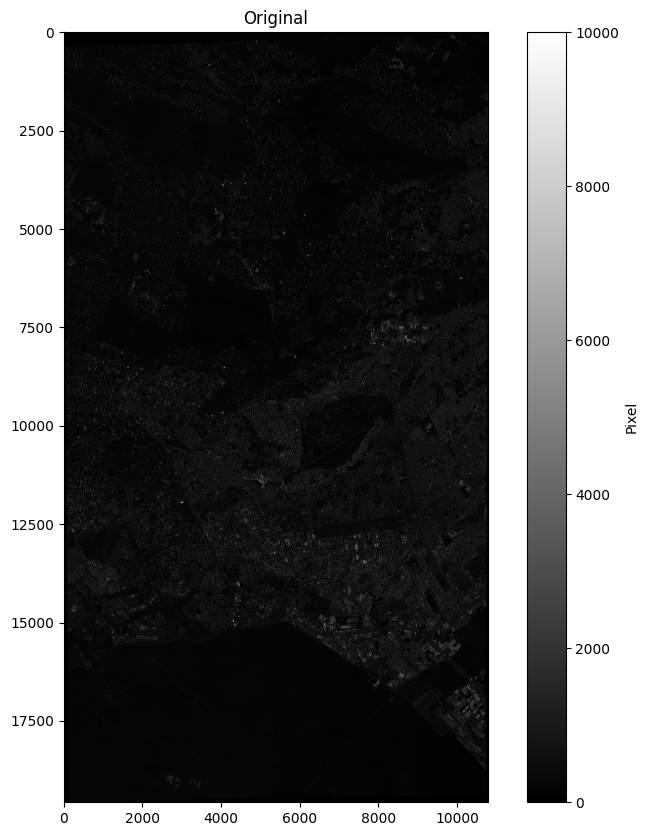

In [2]:
# # 定义图像路径
# image_path = '/Users/wenlanzhang/Downloads/PhD_UCL/Data/RS/Maxar/20231130/MS_merged.tif'

# # 打开图像
# with rasterio.open(image_path) as src:
#     print("图像基本信息：")
#     print(f"宽度: {src.width}, 高度: {src.height}")
#     print(f"波段数: {src.count}")
#     print(f"坐标系: {src.crs}")
#     print(f"地理变换参数: {src.transform}")

#     # 读取第一个波段（仅用于可视化）
#     image = src.read(1)

# # # 可视化图像
# # plt.figure(figsize=(10, 10))
# # plt.imshow(image, cmap='gray')
# # plt.title("Original")
# # plt.colorbar(label="Pixel")
# # plt.show()


# # 定义矢量掩膜路径
# mask_path = '/Users/wenlanzhang/Downloads/PhD_UCL/Data/Waste/RS_Flood/Rectangle.geojson'

# # 加载矢量掩膜
# mask_polygon = gpd.read_file(mask_path)

# # 检查矢量数据
# print("矢量数据基本信息：")
# print(mask_polygon.head())  # 打印前几行数据
# print(f"坐标系: {mask_polygon.crs}")

# # # 可视化矢量掩膜
# # mask_polygon.plot()
# # plt.title("Shp")
# # plt.show()

# # 打开图像
# with rasterio.open(image_path) as src:
#     # 将矢量掩膜转换为GeoJSON格式
#     geometries = mask_polygon.geometry.values
#     geometries = [mapping(geom) for geom in geometries]

#     # 裁剪图像
#     cropped_image, cropped_transform = mask(src, geometries, crop=True)

#     # 更新元数据
#     profile = src.profile
#     profile.update({
#         'height': cropped_image.shape[1],
#         'width': cropped_image.shape[2],
#         'transform': cropped_transform
#     })

# # # 可视化裁剪后的图像
# # plt.figure(figsize=(10, 10))
# # plt.imshow(cropped_image[0], cmap='gray')  # 仅显示第一个波段
# # plt.title("Cliped Image")
# # plt.colorbar(label="Pixel")
# # plt.show()

# # 保存裁剪后的图像
# output_path = '/Users/wenlanzhang/Downloads/cropped_image.tif'

# with rasterio.open(output_path, 'w', **profile) as dst:
#     dst.write(cropped_image)

# print(f"裁剪后的图像已保存到: {output_path}")

# # 这个有个黑边, 不太好, QIS的没有黑边

# 检测是否需要辐射校正

In [10]:
import rasterio

def check_radiometric_correction(file_path):
    with rasterio.open(file_path) as src:
        meta = src.tags()  # 读取元数据
        print(meta)
        if 'RADIOMETRIC_CORRECTION' in meta:
            print(f"辐射校正状态: {meta['RADIOMETRIC_CORRECTION']}")
        if 'PROCESSING_LEVEL' in meta:
            print(f"处理级别: {meta['PROCESSING_LEVEL']}")

# 检查Pre-event和Post-event数据
check_radiometric_correction('/Users/wenlanzhang/Downloads/PhD_UCL/Data/RS/Maxar/20240511/MS/211111023103_105001003B003900-ms.tif')
# check_radiometric_correction('post_event_ge01.tif')

{'AREA_OR_POINT': 'Area'}


In [12]:
def check_pixel_range(file_path):
    with rasterio.open(file_path) as src:
        img = src.read(1)  # 读取第一个波段
        print(f"像素值范围: {img.min()} ~ {img.max()}")
        print(f"数据类型: {img.dtype}")

# check_pixel_range('/Users/wenlanzhang/Downloads/PhD_UCL/Data/RS/Maxar/20240511/MS/211111023103_105001003B003900-ms.tif')
check_pixel_range('/Users/wenlanzhang/Downloads/PhD_UCL/Data/RS/Maxar/20231130/MS/211111032022_104001008E063C00-ms.tif')

像素值范围: 1 ~ 10000
数据类型: uint16


In [16]:
import rasterio
import numpy as np

def check_reflectance(file_path):
    with rasterio.open(file_path) as src:
        dn = src.read(1)  # 读取第一个波段
        reflectance = dn / 10000.0
        print(f"反射率范围: {reflectance.min():.3f} ~ {reflectance.max():.3f}")

        # 检查典型地物（假设影像中有植被、水体）
        row, col = 500, 500  # 根据实际坐标调整
        dn_sample = dn[row, col]
        reflectance_sample = dn_sample / 10000.0
        print(f"示例点 DN 值: {dn_sample} → 反射率: {reflectance_sample:.3f}")

check_reflectance('/Users/wenlanzhang/Downloads/PhD_UCL/Data/RS/Maxar/20240511/MS/211111023103_105001003B003900-ms.tif')

反射率范围: 0.000 ~ 1.000
示例点 DN 值: 0 → 反射率: 0.000


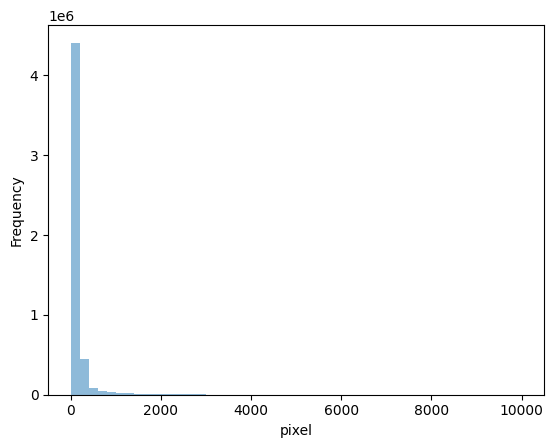

In [18]:
def plot_histogram(file_path, band=1):
    with rasterio.open(file_path) as src:
        img = src.read(band)
        plt.hist(img.flatten(), bins=50, alpha=0.5, label=file_path)

plot_histogram('/Users/wenlanzhang/Downloads/PhD_UCL/Data/RS/Maxar/20240511/MS/211111023103_105001003B003900-ms.tif')
# plot_histogram('post_event_ge01.tif')
plt.xlabel('pixel')
plt.ylabel('Frequency')
# plt.legend()
plt.show()

In [45]:
import rasterio
from rasterio.enums import Resampling
import numpy as np
import matplotlib.pyplot as plt
from skimage.filters import threshold_otsu
from skimage.morphology import remove_small_objects

# Function to load image
def load_image(filepath):
    with rasterio.open(filepath) as src:
        image = src.read()
        profile = src.profile
        transform = src.transform
    return image, profile, transform

# Function to resample raster to match the resolution of another
def resample_raster(source_raster, target_profile):
    resampled_image = np.zeros(
        (source_raster.count, target_profile['height'], target_profile['width']),
        dtype=source_raster.dtypes[0]
    )
    
    for i in range(source_raster.count):
        resampled_image[i] = source_raster.read(
            i + 1,
            out_shape=(target_profile['height'], target_profile['width']),
            resampling=Resampling.bilinear  # Bilinear resampling for smoother results
        )
    
    return resampled_image

# Load Pre-Event (WV03) & Post-Event (GE01)
pre_event_path = flood_base + "Pre_MS.tif"
post_event_path = flood_base + "Post_MS.tif"

pre_image, pre_profile, pre_transform = load_image(pre_event_path)

# Open Post-Event image in read mode
with rasterio.open(post_event_path) as post_src:
    post_image_resampled = resample_raster(post_src, pre_profile)  # Resample to match pre-event
    post_profile = pre_profile  # Update post profile to match pre-event

# Extract Green & NIR Bands for NDWI Calculation
green_pre = pre_image[2, :, :]  # WV03 Band 3 (Green)
nir_pre = pre_image[7, :, :]    # WV03 Band 8 (NIR)

green_post = post_image_resampled[1, :, :]  # GE01 Band 2 (Green) (Resampled)

# Compute NDWI for Pre-Event
ndwi_pre = (green_pre - nir_pre) / (green_pre + nir_pre + 1e-6)

# Estimate NDWI for Post-Event (No NIR Available, use Green Reflectance)
ndwi_post = green_post

# Compute Change in NDWI
delta_ndwi = ndwi_post - ndwi_pre


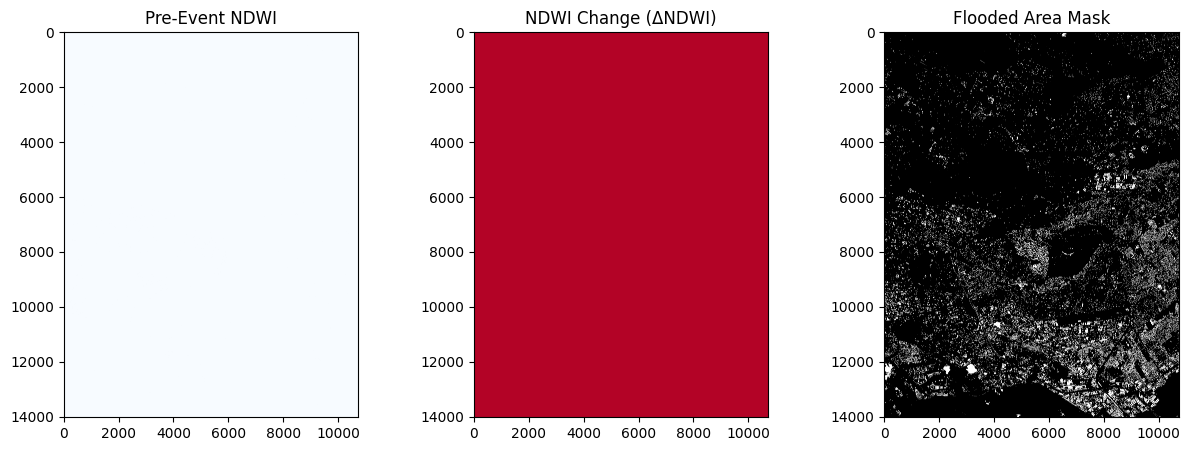

In [46]:
# Apply Thresholding
threshold = threshold_otsu(delta_ndwi)
flood_mask = (delta_ndwi > threshold).astype(np.uint8)

# Remove Small Objects (Noise Reduction)
flood_mask = remove_small_objects(flood_mask.astype(bool), min_size=100).astype(np.uint8)

# Save Flood Mask
flood_mask_output = flood_base + "flood_mask2.tif"
with rasterio.open(
    flood_mask_output,
    'w',
    driver='GTiff',
    height=flood_mask.shape[0],
    width=flood_mask.shape[1],
    count=1,
    dtype=flood_mask.dtype,
    crs=pre_profile['crs'],
    transform=pre_profile['transform']
) as dst:
    dst.write(flood_mask, 1)

# Visualization
fig, ax = plt.subplots(1, 3, figsize=(15, 5))
ax[0].imshow(ndwi_pre, cmap='Blues')
ax[0].set_title("Pre-Event NDWI")
ax[1].imshow(delta_ndwi, cmap='coolwarm', vmin=-0.5, vmax=0.5)
ax[1].set_title("NDWI Change (ΔNDWI)")
ax[2].imshow(flood_mask, cmap='gray')
ax[2].set_title("Flooded Area Mask")

plt.show()


1. Data Preparation  
Before performing flood detection, ensure the datasets are comparable:

- Resample Post-Event Data: WorldView-3 has a higher resolution (0.32m) than GeoEye-1 (0.69m). Use bilinear or cubic resampling to match resolutions.
- Co-register Images: Align images spatially to correct for geometric distortions.
- Atmospheric Correction: Normalize spectral differences caused by different sun angles and atmospheric conditions.

2. Water Body Extraction (Pre-Event)  
Extract pre-existing water bodies to differentiate them from floodwaters.

Use NDWI (Normalized Difference Water Index): NDWI= (Green+NIR)/(Green−NIR)
Green: WorldView-3 Band 3 (510–580 nm)  
NIR: WorldView-3 Band 8 (770–895 nm)  
Threshold: NDWI > 0.2 usually represents water.  
Create a Water Mask: Convert NDWI results into a binary water mask for the pre-event image.

3. Change Detection (Pre vs. Post Event)  
Detect changes that indicate new water accumulation (flooded areas).

a. NDWI Difference
- Compute NDWI for both pre- and post-event images.
- Generate a difference map: ΔNDWI
- Set a threshold (e.g., ΔNDWI > 0.2) to classify new water.

b. SAR-like Water Mapping (if using only RGB)
Since GeoEye-1 does not have NIR, you can use:
- HSV Transformation: Convert RGB to HSV and detect regions with high blue reflectance.
- K-Means Clustering: Group pixels into "water" vs. "non-water" based on brightness.  

c. Texture-Based Flood Detection
If floodwaters have muddy sediment, use:
- Gabor Filters: Identify texture changes.
- Edge Detection (Sobel/Canny): Detect water extent changes.

4. Validation & Refinement  
- Compare with DEM (Digital Elevation Model): Remove water misclassified on high terrain.
- Use Historical Water Masks (JRC Global Surface Water, Sentinel-2, or OpenStreetMap Water Bodies).
- Manual Validation: Compare high-confidence flood areas with external flood reports.

5. Output Generation
- Flood Mask: Binary raster highlighting newly inundated areas.
- Flood Extent Map: Overlay the flood mask onto pre-event imagery for visualization.
- Statistics: Compute total flooded area and percentage increase in water coverage.

1.合并
2.reproject
3.resample
4.clip

In [3]:
import rasterio
import numpy as np
import matplotlib.pyplot as plt
import cv2
import rasterio
import geopandas as gpd
from rasterio.plot import show
from skimage.filters import threshold_otsu
from skimage.morphology import remove_small_objects

In [2]:
# Load Pre-Event (WV03) & Post-Event (GE01)
Base = '/Users/wenlanzhang/Downloads/PhD_UCL/Data/RS/Maxar/'
pre_event_path = Base + "20231130/MS_merged.tif"
post_event_path = Base + "20240511/MS_merged.tif"

pre = '20231130/'
post = '20240511/'
pan_pre_path = Base + pre + "Pan_merged.tif"     # Panchromatic pre-event
ms_pre_path = Base + post +  "MS_merged.tif"       # Multispectral pre-event
pan_post_path = Base + pre +  "Pan_merged.tif"   # Panchromatic post-event
ms_post_path = Base + post + "MS_merged.tif"     # Multispectral post-event
clip_shp_path = '/Users/wenlanzhang/Downloads/PhD_UCL/Data/Waste/RS_Flood/Rectangle.geojson'

In [3]:
# Load Image (Keep Dataset Open)
def load_image(path):
    """Load raster and return dataset object (open)"""
    src = rasterio.open(path)  # Keep dataset open
    img = src.read()           # Read all bands as NumPy array
    return img, src

# Load Data (Keep Open)
# pan_pre, pan_pre_src = load_image(pan_pre_path)
ms_pre, ms_pre_src = load_image(ms_pre_path)
# pan_post, pan_post_src = load_image(pan_post_path)
ms_post, ms_post_src = load_image(ms_post_path)

In [9]:
pan_pre, pan_pre_src = load_image(pan_pre_path)
pan_post, pan_post_src = load_image(pan_post_path)

In [4]:
from rasterio.warp import reproject, calculate_default_transform, Resampling

def reproject_image(src, dst_crs="EPSG:32737"):
    """Reproject image while dataset is open."""
    transform, width, height = calculate_default_transform(
        src.crs, dst_crs, src.width, src.height, *src.bounds
    )
    dst_profile = src.profile.copy()
    dst_profile.update({"crs": dst_crs, "transform": transform, "width": width, "height": height})

    reprojected = np.zeros((src.count, height, width), dtype=src.dtypes[0])

    for i in range(src.count):
        reproject(
            source=src.read(i + 1),
            destination=reprojected[i],
            src_transform=src.transform,
            src_crs=src.crs,
            dst_transform=transform,
            dst_crs=dst_crs,
            resampling=Resampling.bilinear
        )
    return reprojected, dst_profile, transform
    
# Reproject All Images
ms_pre_reproj, ms_pre_profile, ms_pre_transform = reproject_image(ms_pre_src)
ms_post_reproj, ms_post_profile, ms_post_transform = reproject_image(ms_post_src)
# pan_pre_reproj, _, _ = reproject_image(pan_pre_src)
# pan_post_reproj, _, _ = reproject_image(pan_post_src)

In [ ]:
pan_pre_reproj, _, _ = reproject_image(pan_pre_src)
pan_post_reproj, _, _ = reproject_image(pan_post_src)

In [5]:
from rasterio.mask import mask

# Load Shapefile
clip_boundary = gpd.read_file(clip_shp_path)
clip_geom = [shape for shape in clip_boundary.geometry]

def clip_image(image, profile, geometry):
    """Clip image using shapefile geometry."""
    with rasterio.open(image) as src:
        clipped, clipped_transform = mask(src, geometry, crop=True)
    profile.update({"height": clipped.shape[1], "width": clipped.shape[2], "transform": clipped_transform})
    return clipped, profile

# Clip All Images
ms_pre_clipped, ms_pre_profile = clip_image(ms_pre_path, ms_pre_profile, clip_geom)
ms_post_clipped, ms_post_profile = clip_image(ms_post_path, ms_post_profile, clip_geom)
# pan_pre_clipped, _ = clip_image(pan_pre_path, ms_pre_profile, clip_geom)
# pan_post_clipped, _ = clip_image(pan_post_path, ms_post_profile, clip_geom)

In [6]:
def resample_image(image, profile, target_shape, transform):
    """Resample image using bilinear interpolation."""
    resampled = np.zeros((image.shape[0], target_shape[0], target_shape[1]), dtype=image.dtype)
    for i in range(image.shape[0]):
        reproject(
            source=image[i],
            destination=resampled[i],
            src_transform=profile['transform'],
            src_crs=profile['crs'],
            dst_transform=transform,
            dst_crs=profile['crs'],
            resampling=Resampling.bilinear
        )
    return resampled

# Match Post-Event to Pre-Event Shape
target_shape = ms_pre_clipped.shape[1:]
target_transform = ms_pre_profile['transform']

ms_post_resampled = resample_image(ms_post_clipped, ms_post_profile, target_shape, target_transform)
# pan_post_resampled = resample_image(pan_post_clipped, ms_post_profile, target_shape, target_transform)

In [35]:
from rasterio.enums import Resampling
from rasterio.warp import reproject

def resample_image(image, profile, target_shape, target_transform, target_crs):
    """Resample image using rasterio.warp.reproject."""
    resampled = np.zeros((image.shape[0], target_shape[0], target_shape[1]), dtype=image.dtype)

    for i in range(image.shape[0]):
        reproject(
            source=image[i],
            destination=resampled[i],
            src_transform=profile['transform'],
            src_crs=profile['crs'],
            dst_transform=target_transform,
            dst_crs=target_crs,
            resampling=Resampling.bilinear
        )
    return resampled


# Resample Pre-Event to Match Post-Event
target_shape = ms_post.shape[1:]  # (height, width)
target_transform = ms_post_profile['transform']
target_crs = ms_post_profile['crs']

ms_pre_resampled = resample_image(ms_pre, ms_pre_profile, target_shape, target_transform, target_crs)
pan_pre_resampled = resample_image(pan_pre, pan_pre_profile, target_shape, target_transform, target_crs)


# USe

In [10]:
import rasterio
from rasterio.warp import reproject, calculate_default_transform, Resampling
from rasterio.mask import mask
import geopandas as gpd
import numpy as np
import os
import rasterio
from rasterio.enums import Resampling
from shapely.geometry import box

In [11]:
# Load Pre-Event (WV03) & Post-Event (GE01)
Base = '/Users/wenlanzhang/Downloads/PhD_UCL/Data/RS/Maxar/'
pre = '20231130/'
post = '20240511/'
clip_shp = '/Users/wenlanzhang/Downloads/PhD_UCL/Data/Waste/RS_Flood/Rectangle.geojson'

## Clip and Reproject Multispectral (MS) / Panchromatic (PAN) Image

In [2]:
# def process_image(image_path, output_path, dst_crs="EPSG:32737", target_shape=None, target_transform=None, clip_shp_path=None):
def process_image(image_path, output_path, dst_crs="EPSG:32737", clip_shp_path=None):
    """
    Reproject, resample, and clip an image (MS or PAN).
    
    Args:
        image_path (str): Path to the input image.
        output_path (str): Path to save the processed image.
        dst_crs (str): Coordinate reference system to reproject to (default: EPSG:32737).
        target_shape (tuple): Shape (height, width) to resample the image. None if no resampling.
        target_transform (Affine): Transformation of the target image (needed for resampling).
        clip_shp_path (str): Path to the shapefile for clipping.
        
    Returns:
        tuple: (Processed image as numpy array, Raster profile)
    """

    # Open the source image
    with rasterio.open(image_path) as src:
        print(f"\n📂 Processing: {image_path}")
        print(f"Original Shape: {src.shape}, Bands: {src.count}")

        # Get band count dynamically
        band_count = src.count

        # ----------------- 1. Reprojection -----------------
        transform, width, height = calculate_default_transform(
            src.crs, dst_crs, src.width, src.height, *src.bounds
        )
        
        dst_profile = src.profile.copy()
        dst_profile.update({"crs": dst_crs, "transform": transform, "width": width, "height": height})
        
        reprojected = np.zeros((band_count, height, width), dtype=src.dtypes[0])
        
        for i in range(band_count):
            reproject(
                source=src.read(i + 1),
                destination=reprojected[i],
                src_transform=src.transform,
                src_crs=src.crs,
                dst_transform=transform,
                dst_crs=dst_crs,
                resampling=Resampling.bilinear
            )

        print(f"✅ Reprojected to {dst_crs} - Shape: {reprojected.shape}")

        # ----------------- 2. Clipping -----------------
        if clip_shp_path:
            clip_boundary = gpd.read_file(clip_shp_path)
            clip_geom = [geom for geom in clip_boundary.geometry]
            with rasterio.open(image_path) as src_clip:
                clipped, clipped_transform = mask(src_clip, clip_geom, crop=True)
            reprojected = clipped
            transform = clipped_transform
            dst_profile.update({"height": clipped.shape[1], "width": clipped.shape[2], "transform": transform})
            print(f"✅ Clipped - Shape: {reprojected.shape}")

        # ----------------- 3. Save Output -----------------
        dst_profile.update({"height": reprojected.shape[1], "width": reprojected.shape[2], "count": band_count})
        os.makedirs(os.path.dirname(output_path), exist_ok=True)
        with rasterio.open(output_path, 'w', **dst_profile) as dst:
            dst.write(reprojected)
        print(f"💾 Saved: {output_path}")

    return reprojected, dst_profile


In [4]:
ms_pre, ms_pre_profile = process_image(
    image_path = Base + pre + "MS_merged.tif",
    output_path = Base + pre + "MS_pre_processed.tif",
    dst_crs = "EPSG:32737",
    clip_shp_path = clip_shp
)


📂 Processing: /Users/wenlanzhang/Downloads/PhD_UCL/Data/RS/Maxar/20231130/MS_merged.tif
Original Shape: (19568, 10795), Bands: 8
✅ Reprojected to EPSG:32737 - Shape: (8, 19568, 10795)
✅ Clipped - Shape: (8, 13975, 10610)
💾 Saved: /Users/wenlanzhang/Downloads/PhD_UCL/Data/RS/Maxar/20231130/MS_pre_processed.tif


In [5]:
pan_pre, pan_pre_profile = process_image(
    image_path = Base + pre + "Pan_merged.tif",
    output_path = Base + pre + "Pan_pre_processed.tif",
    dst_crs = "EPSG:32737",
    clip_shp_path = clip_shp
)


📂 Processing: /Users/wenlanzhang/Downloads/PhD_UCL/Data/RS/Maxar/20231130/Pan_merged.tif
Original Shape: (78272, 43182), Bands: 1
✅ Reprojected to EPSG:32737 - Shape: (1, 78272, 43182)
✅ Clipped - Shape: (1, 55895, 42436)
💾 Saved: /Users/wenlanzhang/Downloads/PhD_UCL/Data/RS/Maxar/20231130/Pan_pre_processed.tif


In [6]:
ms_post, ms_post_profile = process_image(
    image_path = Base + post + "MS_merged.tif",
    output_path = Base + post + "MS_post_processed.tif",
    dst_crs = "EPSG:32737",
    clip_shp_path = clip_shp
)


📂 Processing: /Users/wenlanzhang/Downloads/PhD_UCL/Data/RS/Maxar/20240511/MS_merged.tif
Original Shape: (11484, 11811), Bands: 4
✅ Reprojected to EPSG:32737 - Shape: (4, 11484, 11811)
✅ Clipped - Shape: (4, 7511, 5702)
💾 Saved: /Users/wenlanzhang/Downloads/PhD_UCL/Data/RS/Maxar/20240511/MS_post_processed.tif


In [8]:
pan_post, pan_post_profile = process_image(
    image_path = Base + post + "Pan_merged.tif",
    output_path = Base + post + "Pan_post_processed.tif",
    dst_crs = "EPSG:32737",
    clip_shp_path = clip_shp
)


📂 Processing: /Users/wenlanzhang/Downloads/PhD_UCL/Data/RS/Maxar/20240511/Pan_merged.tif
Original Shape: (45918, 47220), Bands: 1
✅ Reprojected to EPSG:32737 - Shape: (1, 45918, 47220)
✅ Clipped - Shape: (1, 30025, 22795)
💾 Saved: /Users/wenlanzhang/Downloads/PhD_UCL/Data/RS/Maxar/20240511/Pan_post_processed.tif


## Resample Post Multispectral (MS) / Panchromatic (PAN) Image

In [17]:
# # Resampled but doesn't overlap with the pixcel

# import rasterio
# from rasterio.enums import Resampling
# from rasterio.warp import calculate_default_transform, reproject

# # Paths to your source and target raster files
# low_res_path = Base + post + "MS_post_processed.tif"
# high_res_path = Base + pre + "MS_pre_processed.tif"
# output_path = Base + post + "MS_post_processed_resample.tif"

# # Open the high-resolution raster to get its parameters
# with rasterio.open(high_res_path) as high_res_dataset:
#     high_res_transform = high_res_dataset.transform
#     high_res_crs = high_res_dataset.crs
#     high_res_width = high_res_dataset.width
#     high_res_height = high_res_dataset.height
#     high_res_resolution = high_res_dataset.res

# # Open the low-resolution raster to resample
# with rasterio.open(low_res_path) as low_res_dataset:
#     # Calculate the transform and dimensions for the resampled raster
#     transform, width, height = calculate_default_transform(
#         low_res_dataset.crs, high_res_crs, low_res_dataset.width, low_res_dataset.height, *low_res_dataset.bounds,
#         dst_width=high_res_width, dst_height=high_res_height
#     )

#     # Update the metadata for the resampled raster
#     resampled_meta = low_res_dataset.meta.copy()
#     resampled_meta.update({
#         'crs': high_res_crs,
#         'transform': transform,
#         'width': width,
#         'height': height
#     })

#     # Perform the resampling
#     with rasterio.open(output_path, 'w', **resampled_meta) as resampled_dataset:
#         for i in range(1, low_res_dataset.count + 1):
#             reproject(
#                 source=rasterio.band(low_res_dataset, i),
#                 destination=rasterio.band(resampled_dataset, i),
#                 src_transform=low_res_dataset.transform,
#                 src_crs=low_res_dataset.crs,
#                 dst_transform=transform,
#                 dst_crs=high_res_crs,
#                 resampling=Resampling.bilinear
#             )

# print(f"Resampled raster saved to {output_path}")


Resampled raster saved to /Users/wenlanzhang/Downloads/PhD_UCL/Data/RS/Maxar/20240511/MS_post_processed_resample.tif


In [4]:
import rasterio
from rasterio.enums import Resampling
from shapely.geometry import box

# Paths
high_res_path = Base + pre + "Pan_pre_processed.tif"
low_res_path = Base + post + "Pan_post_processed.tif"
output_high_path = Base + pre + "Pan_pre_processed_croped.tif"
output_low_path = Base + post + "Pan_post_processed_croped.tif"

# Open both rasters
with rasterio.open(high_res_path) as high_res_dataset, rasterio.open(low_res_path) as low_res_dataset:
    # Check if both rasters have non-zero bounds
    if high_res_dataset.bounds and low_res_dataset.bounds:
        # Get bounds of both rasters
        high_bounds = box(*high_res_dataset.bounds)
        low_bounds = box(*low_res_dataset.bounds)

        # Calculate intersection bounds
        intersect_bounds = high_bounds.intersection(low_bounds)
        
        # Handle the case when there is no intersection
        if intersect_bounds.is_empty:
            raise ValueError("❗ No intersection found between the two rasters. Please check your input files.")
        
        intersect_bounds = intersect_bounds.bounds

        # Clip high-resolution raster
        high_window = rasterio.windows.from_bounds(*intersect_bounds, high_res_dataset.transform)
        high_res_clipped = high_res_dataset.read(window=high_window)
        high_res_profile = high_res_dataset.profile
        high_res_profile.update({
            'width': high_window.width,
            'height': high_window.height,
            'transform': high_res_dataset.window_transform(high_window)
        })

        # Save clipped high-resolution raster
        with rasterio.open(output_high_path, 'w', **high_res_profile) as dst:
            dst.write(high_res_clipped)

        # Clip low-resolution raster
        low_window = rasterio.windows.from_bounds(*intersect_bounds, low_res_dataset.transform)
        low_res_clipped = low_res_dataset.read(window=low_window)
        low_res_profile = low_res_dataset.profile
        low_res_profile.update({
            'width': low_window.width,
            'height': low_window.height,
            'transform': low_res_dataset.window_transform(low_window)
        })

        # Save clipped low-resolution raster
        with rasterio.open(output_low_path, 'w', **low_res_profile) as dst:
            dst.write(low_res_clipped)

        print("✅ Both rasters have been clipped to their intersection and saved.")
    else:
        raise ValueError("❗ One or both rasters have zero bounds. Please check your input files.")


/opt/miniconda3/envs/Try/lib/python3.10/site-packages/shapely/set_operations.py:133: RuntimeWarning: invalid value encountered in intersection
  return lib.intersection(a, b, **kwargs)


✅ Both rasters have been clipped to their intersection and saved.


In [5]:
from rasterio.warp import reproject

output_resampled_path = Base + post + "Pan_post_processed_resample.tif"

with rasterio.open(output_high_path) as high_res_dataset, rasterio.open(output_low_path) as low_res_dataset:
    transform = high_res_dataset.transform
    width = high_res_dataset.width
    height = high_res_dataset.height
    crs = high_res_dataset.crs

    # Update metadata for the resampled raster
    resampled_meta = low_res_dataset.meta.copy()
    resampled_meta.update({
        'transform': transform,
        'width': width,
        'height': height,
        'crs': crs
    })

    # Perform resampling
    with rasterio.open(output_resampled_path, 'w', **resampled_meta) as dst:
        for i in range(1, low_res_dataset.count + 1):
            reproject(
                source=rasterio.band(low_res_dataset, i),
                destination=rasterio.band(dst, i),
                src_transform=low_res_dataset.transform,
                src_crs=low_res_dataset.crs,
                dst_transform=transform,
                dst_crs=crs,
                resampling=Resampling.bilinear
            )

print("✅ Low-resolution raster has been resampled and saved.")


✅ Low-resolution raster has been resampled and saved.


## Compute NDWI & ΔNDWI

In [38]:
import rasterio
import numpy as np
import matplotlib.pyplot as plt

def load_image(filepath):
    """Load a multispectral image using Rasterio."""
    with rasterio.open(filepath) as src:
        image = src.read()  # Read all bands
        profile = src.profile
    return image, profile

# File Paths
ms_pre_path = Base + pre + "MS_pre_processed_croped.tif"
ms_post_path = Base + post + "MS_post_processed_resample.tif"

# Load Images
ms_pre, ms_pre_profile = load_image(ms_pre_path)
ms_post, ms_post_profile = load_image(ms_post_path)

print(f"Pre-Event Image Shape: {ms_pre.shape}")
print(f"Post-Event Image Shape: {ms_post.shape}")

Pre-Event Image Shape: (8, 13975, 10609)
Post-Event Image Shape: (4, 13975, 10609)


In [39]:
def compute_ndwi(green, nir=None):
    """Compute NDWI using Green and NIR, or just Green if NIR is unavailable."""
    if nir is not None:
        return (green - nir) / (green + nir + 1e-6)  # Avoid division by zero
    else:
        return green / 65535.0  # Normalize green reflectance than 255

def mask_zero_values(array):
    """Replace zero values with NaN to avoid affecting NDWI calculations."""
    array = np.where(array == 0, np.nan, array)  # Convert 0 to NaN
    return array

In [40]:
# import numpy as np

# def compute_ndwi(green, nir=None, bit_depth=16):
#     """Compute NDWI using Green and NIR bands."""
#     if nir is not None:
#         denominator = (green + nir + 1e-6)  # Avoid division by zero
#         return (green - nir) / denominator
#     else:
#         # Normalize to [0, 1] based on sensor bit depth (16-bit by default)
#         return green / (2**bit_depth - 1)  # e.g., 65535 for 16-bit

# def mask_zero_values(array):
#     """Replace zero values with NaN."""
#     return np.where(array == 0, np.nan, array)

In [41]:
# Extract Green and NIR Bands
green_pre = ms_pre[1]  # Green Band (Index 1, zero-based indexing)
nir_pre = ms_pre[7]    # NIR Band (Index 7 for WV03 multispectral)

green_post = ms_post[1]  # Green Band (Index 1 for GE01, no NIR available)

# Mask Zero Values
green_pre = mask_zero_values(green_pre)
nir_pre = mask_zero_values(nir_pre)
# green_post = mask_zero_values(green_post)

print(f"Green Pre Shape: {green_pre.shape}, NIR Pre Shape: {nir_pre.shape}")
print(f"Green Post Shape: {green_post.shape}")

Green Pre Shape: (13975, 10609), NIR Pre Shape: (13975, 10609)
Green Post Shape: (13975, 10609)


In [42]:
# Calculate NDWI
ndwi_pre = compute_ndwi(green_pre, nir_pre)   # Using Green and NIR for WV03
ndwi_post = compute_ndwi(green_post)          # Using only Green for GE01

# Calculate ΔNDWI (Post - Pre)
delta_ndwi = ndwi_post - ndwi_pre

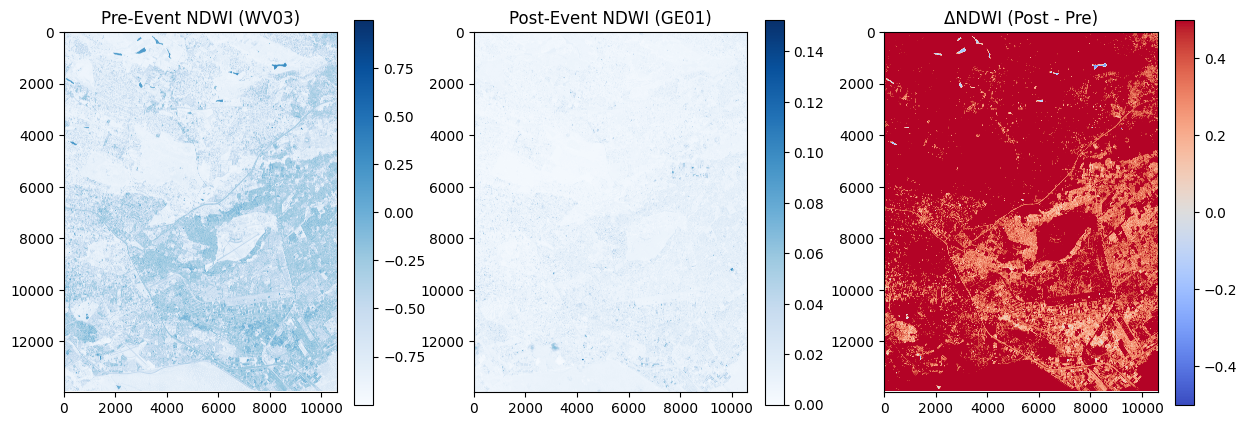

In [43]:
# Visualization
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(ndwi_pre, cmap='Blues')
plt.title("Pre-Event NDWI (WV03)")
plt.colorbar()

plt.subplot(1, 3, 2)
plt.imshow(ndwi_post, cmap='Blues')
plt.title("Post-Event NDWI (GE01)")
plt.colorbar()

plt.subplot(1, 3, 3)
plt.imshow(delta_ndwi, cmap='coolwarm', vmin=-0.5, vmax=0.5)
plt.title("ΔNDWI (Post - Pre)")
plt.colorbar()

plt.show()

In [44]:
def save_geotiff(array, profile, output_path):
    """Save a single-band array as a GeoTIFF."""
    profile.update({
        "count": 1,
        "dtype": array.dtype,
        "driver": "GTiff"
    })

    with rasterio.open(output_path, 'w', **profile) as dst:
        dst.write(array, 1)
    print(f"Saved: {output_path}")

# Save Output Files
save_geotiff(ndwi_pre, ms_pre_profile, Base + pre + "pre_NDWI.tif")
save_geotiff(ndwi_post, ms_post_profile, Base + post + "post_NDWI.tif")
save_geotiff(delta_ndwi, ms_pre_profile, "/Users/wenlanzhang/Downloads/PhD_UCL/Data/Waste/RS_Flood/delta_ndwi.tif")

Saved: /Users/wenlanzhang/Downloads/PhD_UCL/Data/RS/Maxar/20231130/pre_NDWI.tif
Saved: /Users/wenlanzhang/Downloads/PhD_UCL/Data/RS/Maxar/20240511/post_NDWI.tif
Saved: /Users/wenlanzhang/Downloads/PhD_UCL/Data/Waste/RS_Flood/delta_ndwi.tif


In [45]:
import numpy as np
import pandas as pd

def get_statistics(array, name="Array"):
    """Calculate and display basic statistics of the NDWI array."""
    array_flat = array.flatten()  # Flatten array to 1D
    array_flat = array_flat[~np.isnan(array_flat)]  # Remove NaNs

    stats = {
        "Name": name,
        "Mean": np.mean(array_flat),
        "Median": np.median(array_flat),
        "Min": np.min(array_flat),
        "Max": np.max(array_flat),
        "Std Dev": np.std(array_flat),
        "Pixel Count": array_flat.size
    }

    return pd.Series(stats)

# Display Statistics
ndwi_pre_stats = get_statistics(ndwi_pre, name="Pre-Event NDWI (WV03)")
ndwi_post_stats = get_statistics(ndwi_post, name="Post-Event NDWI (GE01)")
delta_ndwi_stats = get_statistics(delta_ndwi, name="ΔNDWI (Post - Pre)")

df_stats = pd.DataFrame([ndwi_pre_stats, ndwi_post_stats, delta_ndwi_stats])
# print(df_stats)
df_stats

,Name,Mean,Median,Min,Max,Std Dev,Pixel Count
0,Pre-Event NDWI (WV03),-0.600948,-0.683386,-0.999776,0.999761,0.270551,148225584
1,Post-Event NDWI (GE01),0.010143,0.008225,0.000000,0.152590,0.008213,148260775
2,ΔNDWI (Post - Pre),0.611093,0.692418,-0.998434,1.150590,0.267084,148225584


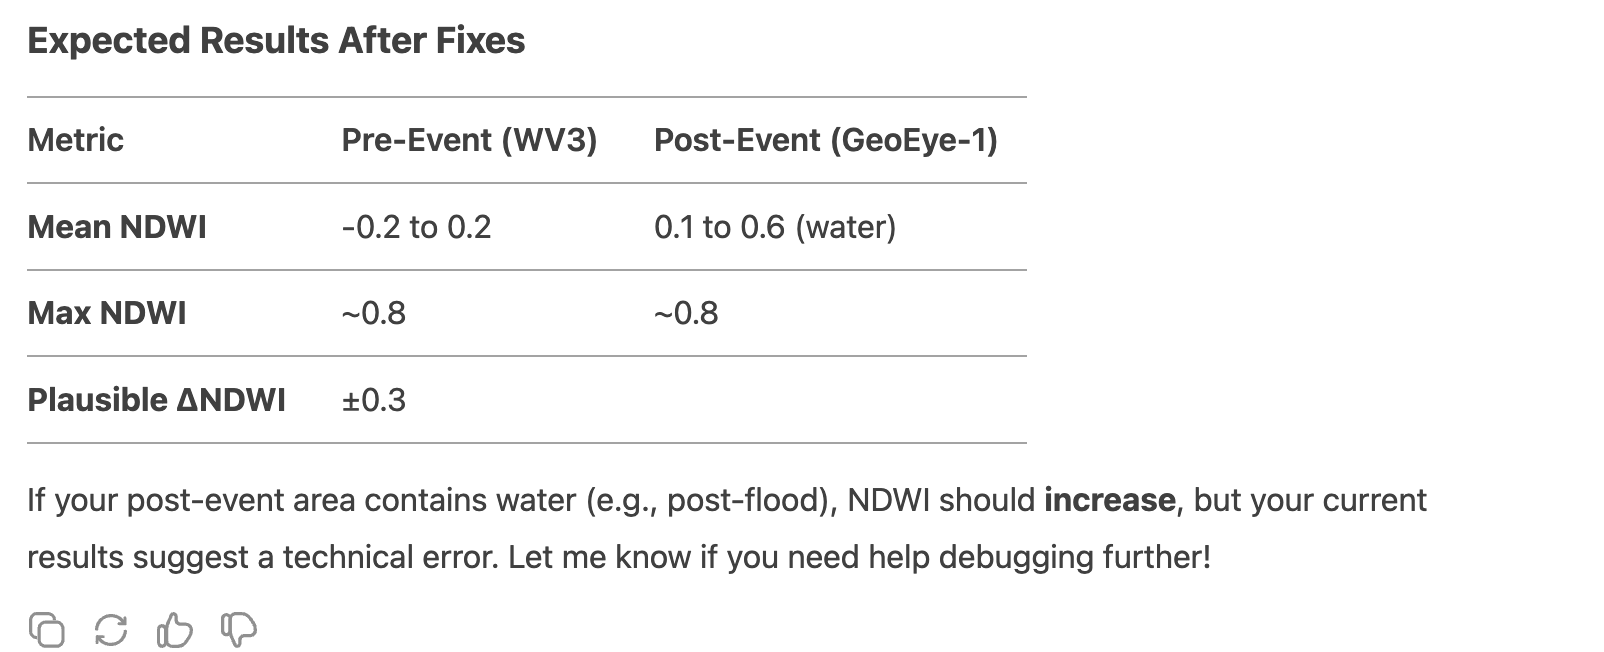

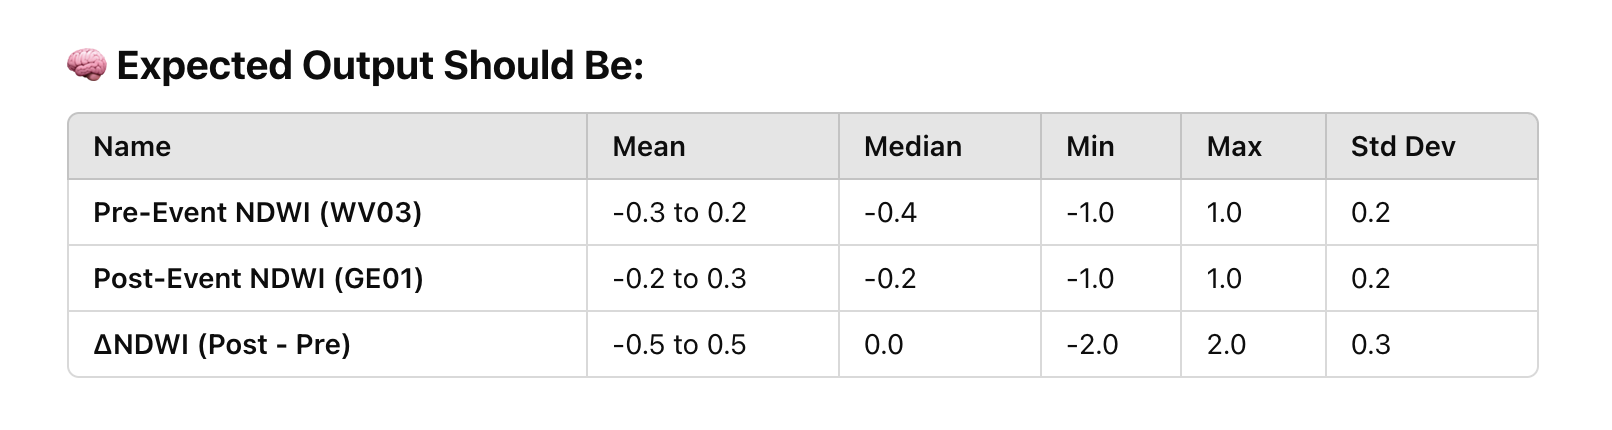

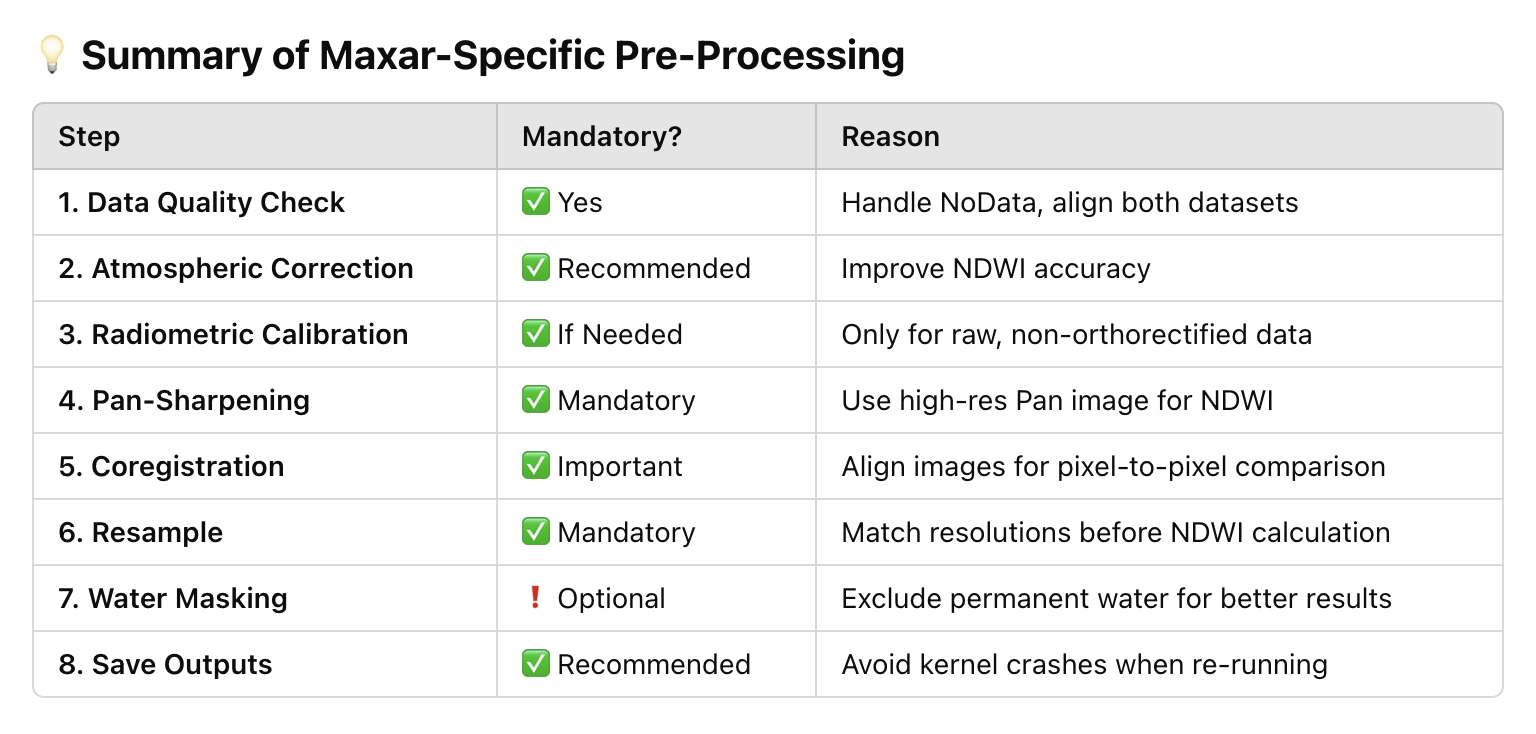
✅ 2. Atmospheric Correction — Optional  
✅ 3. Radiometric Calibration — Required  

In [10]:
# Extract Bands
# WorldView-3 (Pre-Event) - Assume 8-band MS
green_pre = pre_image[2, :, :]  # Band 3 (Green)
nir_pre = pre_image[7, :, :]    # Band 8 (NIR)

# GeoEye-1 (Post-Event) - Assume 4-band MS
green_post = post_image[1, :, :]  # Band 2 (Green) - No NIR Available

# Compute NDWI for pre-event
ndwi_pre = compute_ndwi(green_pre, nir_pre)
ndwi_post = green_post  # No NIR in GeoEye-1, use Green Reflectance directly

# Compute Difference NDWI
delta_ndwi = ndwi_post - ndwi_pre


ValueError: operands could not be broadcast together with shapes (11484,11811) (19568,10795) 

In [ ]:

# Generate Flood Mask
flood_mask = apply_threshold(delta_ndwi)

# Remove Small Noise
flood_mask = remove_small_objects(flood_mask.astype(bool), min_size=100).astype(np.uint8)

# Save Flood Mask
flood_mask_output = "flood_mask.tif"
with rasterio.open(
    flood_mask_output,
    'w',
    driver='GTiff',
    height=flood_mask.shape[0],
    width=flood_mask.shape[1],
    count=1,
    dtype=flood_mask.dtype,
    crs=pre_profile['crs'],
    transform=pre_profile['transform']
) as dst:
    dst.write(flood_mask, 1)

# Visualization
fig, ax = plt.subplots(1, 3, figsize=(15, 5))
ax[0].imshow(ndwi_pre, cmap='Blues')
ax[0].set_title("Pre-Event NDWI")
ax[1].imshow(delta_ndwi, cmap='coolwarm', vmin=-0.5, vmax=0.5)
ax[1].set_title("NDWI Change (ΔNDWI)")
ax[2].imshow(flood_mask, cmap='gray')
ax[2].set_title("Flooded Area Mask")

plt.show()


# SAR
Synthetic Aperture Radar (SAR) data comes from different satellites and sensors, each with varying spatial, temporal, and radiometric resolutions. Below are some of the most common SAR datasets and their key specifications:

1. Sentinel-1 (ESA)
Resolution: 10m (IW mode), 20m (EW mode), 40m (Wave mode)
Frequency Band: C-band (5.405 GHz)
Polarization: VV, VH, HH, HV
Revisit Time: 6–12 days (depending on location)
Data Access: Free and open (via Copernicus Open Access Hub)
2. ALOS-2 PALSAR (JAXA)
Resolution: 3m (Spotlight), 10m (Stripmap), 100m (ScanSAR)
Frequency Band: L-band (1.27 GHz)
Polarization: HH, HV, VV, VH
Revisit Time: 14 days
Data Access: Partially open (free low-resolution data, paid high-resolution data)
3. RADARSAT-1 & RADARSAT-2 (CSA)
Resolution: 3m (Spotlight), 8–100m (various modes)
Frequency Band: C-band (5.405 GHz)
Polarization: HH, HV, VV, VH (fully polarimetric)
Revisit Time: 24 days (RADARSAT-1), variable (RADARSAT-2)
Data Access: Commercial (RADARSAT-2), older RADARSAT-1 data freely available
4. TerraSAR-X & TanDEM-X (DLR)
Resolution: 0.25m (Spotlight), 1m (Stripmap), 18m (ScanSAR)
Frequency Band: X-band (9.65 GHz)
Polarization: HH, HV, VV, VH (dual-pol)
Revisit Time: 11 days (constellation with TanDEM-X)
Data Access: Commercial
5. COSMO-SkyMed (ASI)
Resolution: 1m (Spotlight), 3–30m (Stripmap & ScanSAR)
Frequency Band: X-band (9.6 GHz)
Polarization: HH, HV, VV, VH
Revisit Time: 1–16 days (constellation)
Data Access: Commercial
6. ICEYE (Commercial, Finland)
Resolution: 0.5m–3m (Spotlight), 15m (Stripmap)
Frequency Band: X-band
Polarization: HH (single-pol)
Revisit Time: Multiple times per day
Data Access: Commercial
7. Capella Space
Resolution: 0.5m (Spotlight), 2m (Stripmap)
Frequency Band: X-band
Polarization: Single or dual-pol
Revisit Time: Sub-daily
Data Access: Commercial
8. NISAR (NASA-ISRO, planned for 2024)
Resolution: 3–10m
Frequency Band: L-band & S-band
Polarization: Fully polarimetric (HH, HV, VH, VV)
Revisit Time: 12 days
Data Access: Free and open (expected)
